# Convolution

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import tensorflow as tf

## 1D convolution
`sp.signal.convolve(x, h, mode = )`

In [2]:
x = np.array([1,2,3,4])
h = np.array([0.5, 0.5])
sp.signal.convolve(x, h, mode = 'same')

array([0.5, 1.5, 2.5, 3.5])

Convolution is linear, so $x*h$ can be expressed as a matrix multiplied by $x$. We call this matrix $M_h$, as its determined by $h$. In particular, $M_h$ is a Toeplitz matrix, which can be determined by the first row and first column.

In [3]:
c = np.array([0.5, 0.5, 0, 0]) # first col
r = np.array([0.5, 0, 0, 0]) # first row
Mh = sp.linalg.toeplitz(c, r)
Mh

array([[0.5, 0. , 0. , 0. ],
       [0.5, 0.5, 0. , 0. ],
       [0. , 0.5, 0.5, 0. ],
       [0. , 0. , 0.5, 0.5]])

$$x*h = M_h x$$

In [4]:
Mh@x.reshape([-1,1])

array([[0.5],
       [1.5],
       [2.5],
       [3.5]])

## 2D convolution

## Effects on images

In [5]:
img = plt.imread("../data/hen.jpeg")
img.shape

(3024, 4032, 3)

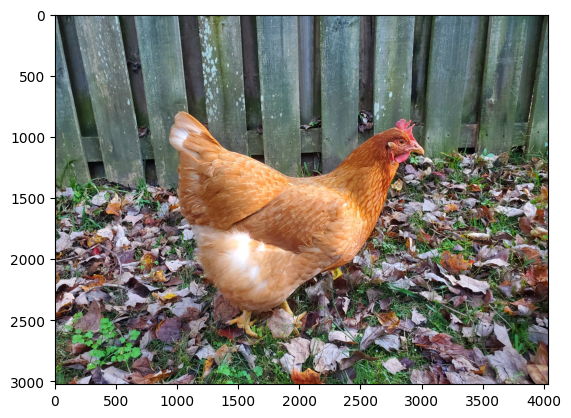

In [6]:
plt.imshow(img);

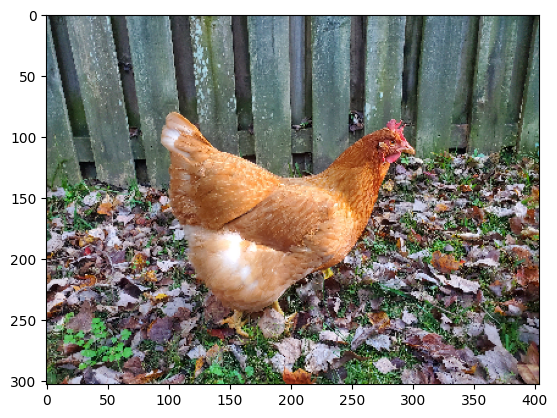

In [7]:
# downsize/subsample
# taking every 10th of the row, every 10th of the column, and all 3 channels
img_small = img[::10, ::10,:]
plt.imshow(img_small);

## A convolution that blurs the image

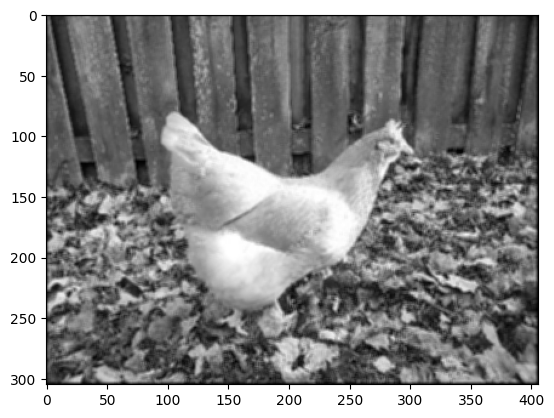

In [8]:
blur = np.ones([3,3])/9
img_small_blur = sp.signal.convolve2d(img_small[:,:,0], blur)
plt.imshow(img_small_blur, cmap = 'gray');

## A convolution that shows the horizontal difference of an image

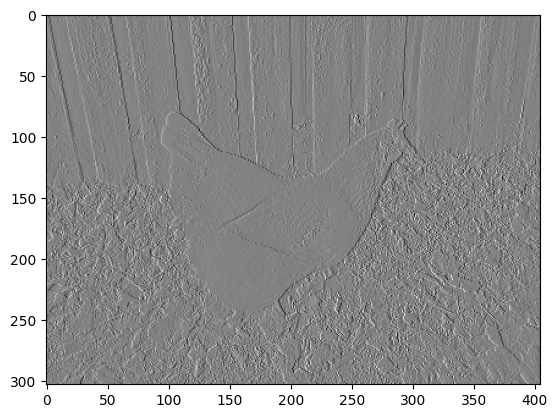

In [14]:
h_diff = np.array([[1,-1]])
img_small_hdiff = sp.signal.convolve2d(img_small[:,:,0], h_diff)
plt.imshow(img_small_hdiff, cmap = 'gray');

## A convolution that shows the vertical difference of an image

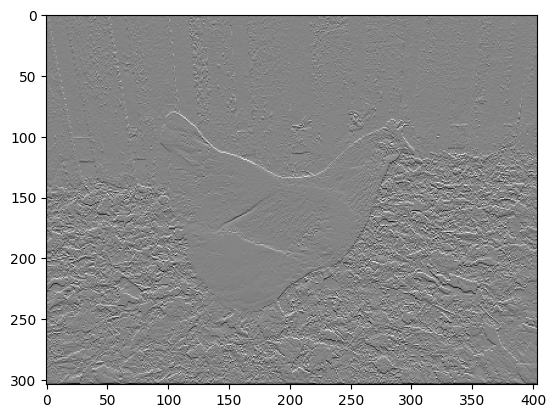

In [15]:
v_diff = np.array([1,-1]).reshape([-1,1]) # a column vector
img_small_vdiff = sp.signal.convolve2d(img_small[:,:,0], v_diff)
plt.imshow(img_small_vdiff, cmap = 'gray');

In [16]:
v_diff

array([[ 1],
       [-1]])

In the above, we used 3 different kernels:
- average kernel
- vertical difference kernel
- horizontal difference kernel

The idea of CNN is that we will extract the features of an image very effectively by convolving the image with various kernels. What are these kernels? These are part of the parameters that will be trained!

## Pooling

A typical layer of a CNN consists of three stages. 
- In the first stage, the layer performs several convolutions in parallel to produce a set of linear activations.
- In the 2nd stage, each linear activation is run through a nonlinear activation function, such as relu.
- In the 3rd stage, we use a **pooling function** to modify the output of the layer further.

A pooling function replaces the output of the net at a certain location with a summary statistic of the nearby outputs. **Max Pooling** is particularly popular.

The point of pooling is to make the representation approximately **invariant** to small translations of the input.

We will use a 1D example: max pooling using nearby 3 coordinates.

|  | | | | | | | | | | |
|:--|--|--|--|--|--|:--|--|--|--|--|
|input 1|0.1|1|0.2|0.1||input 2|0.3|0.1|1|0.2|
|output 1 after max pooling|1|1|1|0.2||output 2 after max pooling|0.3|1|1|1|





In [17]:
img_small_vdiff.shape

(304, 404)

(1, 304, 404, 1)
(1, 152, 202, 1)


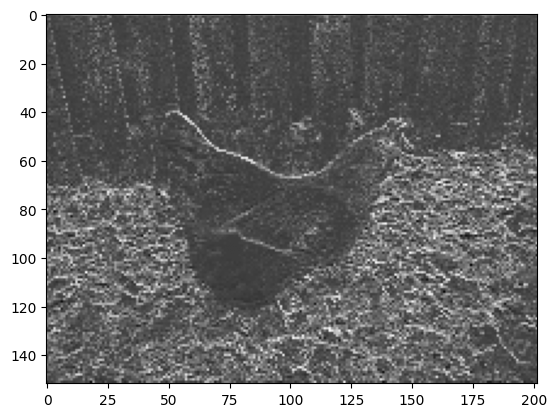

In [22]:
# we will be using the max pooling function from tensorflow
max_pool_2d = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))

# we need to reshape 'img_small_hdiff' to a 4D array before feeding to the max_pool_2d() function
img_small_vdiff_4 = img_small_vdiff.reshape([1, img_small_vdiff.shape[0], img_small_vdiff.shape[1], 1])
print(img_small_vdiff_4.shape)
pooled = max_pool_2d(img_small_vdiff_4)

# after going through the max_pool function, it becoems a tensor object
pooled = np.array(pooled)
print(pooled.shape)
# show image
pooled = pooled.reshape([pooled.shape[1], pooled.shape[2]])
plt.imshow(pooled, cmap = 'gray');